In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

In [ ]:
uploaded = files.upload()
image_name_1 = next(iter(uploaded))
color_image_path = '/content/' + image_name_1
print('Selected the color image (color.png):', color_image_path)

Saving color.png to color.png
Selected the color image (color.png): /content/color.png


Text(0.5, 1.0, 'All Channel')

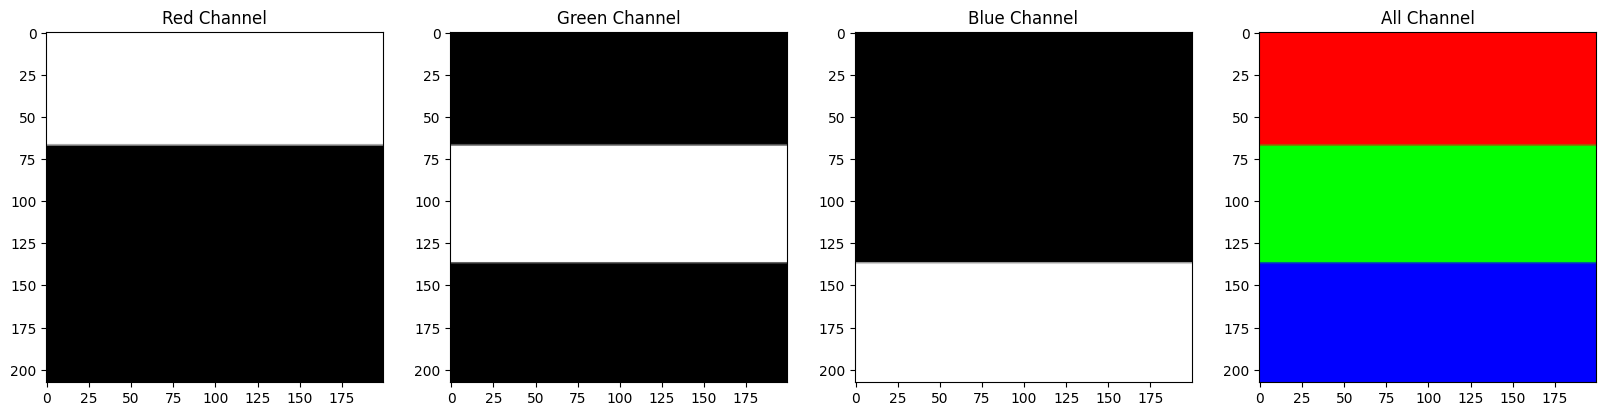

In [ ]:
img = cv2.imread(color_image_path)
b, g, r = cv2.split(img)

plt.figure(figsize=([20, 5]))
plt.subplot(141);plt.imshow(r, cmap='gray');plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap='gray');plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap='gray');plt.title("Blue Channel")

plt.subplot(144);plt.imshow(img[:, :, ::-1]);plt.title("All Channel")

In [ ]:
uploaded = files.upload()
image_name_2 = next(iter(uploaded))
input_image_path = '/content/' + image_name_2
print('Selected the input image (input.jpg):', input_image_path)

Saving input.jpg to input.jpg
Selected the input image (input.jpg): /content/input.jpg


Text(0.5, 1.0, 'All Channel')

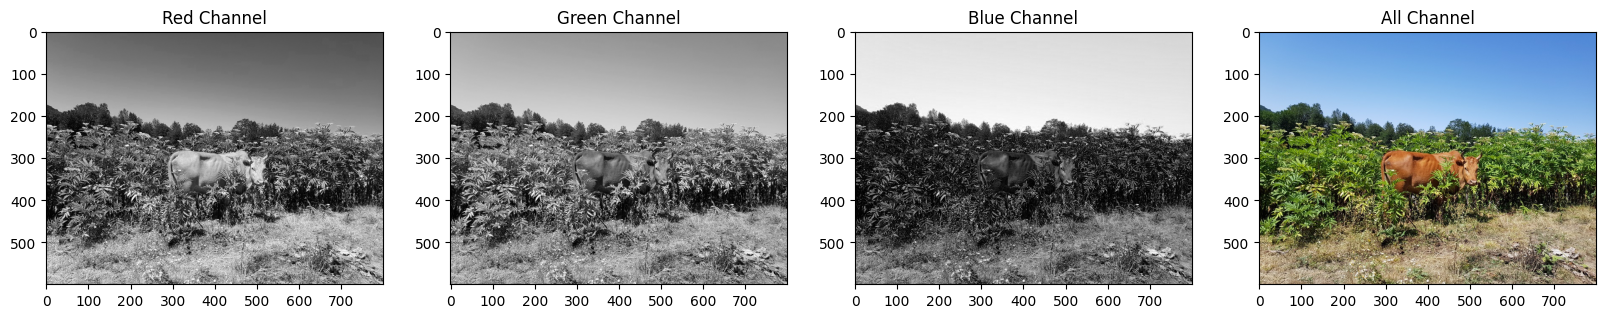

In [ ]:
img = cv2.imread(input_image_path)
b, g, r = cv2.split(img)

plt.figure(figsize=([20, 5]))
plt.subplot(141);plt.imshow(r, cmap='gray');plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap='gray');plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap='gray');plt.title("Blue Channel")

plt.subplot(144);plt.imshow(img[:, :, ::-1]);plt.title("All Channel")

Text(0.5, 1.0, 'merged output')

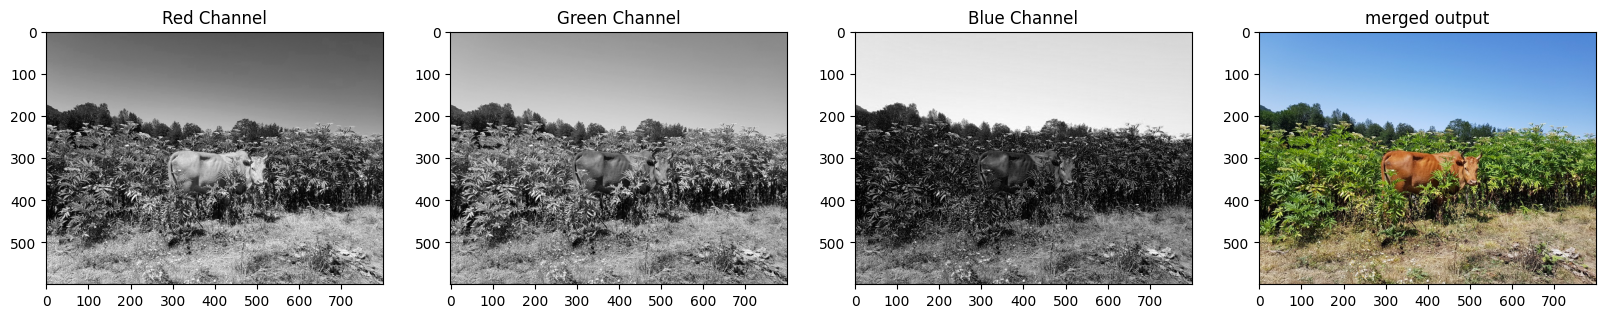

In [ ]:
merged = cv2.merge([b, g, r])

plt.figure(figsize=([20, 5]))
plt.subplot(141);plt.imshow(r, cmap='gray');plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap='gray');plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap='gray');plt.title("Blue Channel")

plt.subplot(144);plt.imshow(merged[:, :, ::-1]);plt.title("merged output")

Text(0.5, 1.0, 'Blue')

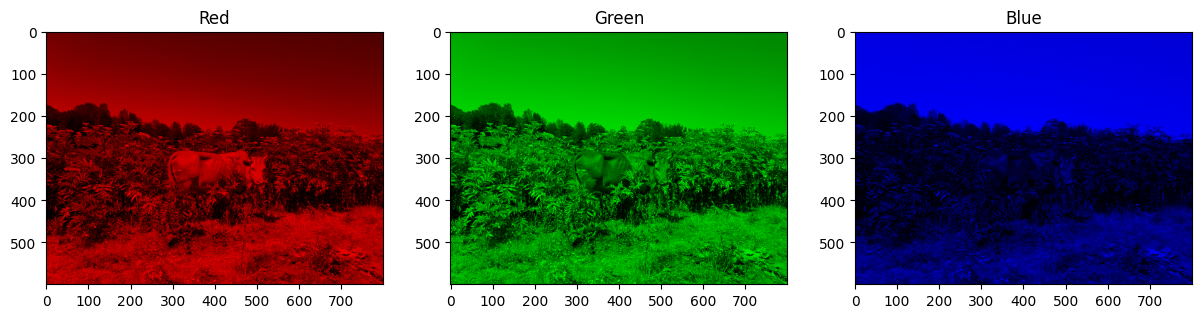

In [ ]:
zeros = np.zeros_like(r, 'uint8')

red = cv2.merge([zeros, zeros, r])
green = cv2.merge([zeros, g, zeros])
blue = cv2.merge([b, zeros, zeros])

plt.figure(figsize=([20, 5]))
plt.subplot(141);plt.imshow(red[..., ::-1], cmap='gray');plt.title("Red")
plt.subplot(142);plt.imshow(green[..., ::-1], cmap='gray');plt.title("Green")
plt.subplot(143);plt.imshow(blue[..., ::-1], cmap='gray');plt.title("Blue")

Text(0.5, 1.0, 'Modified Image')

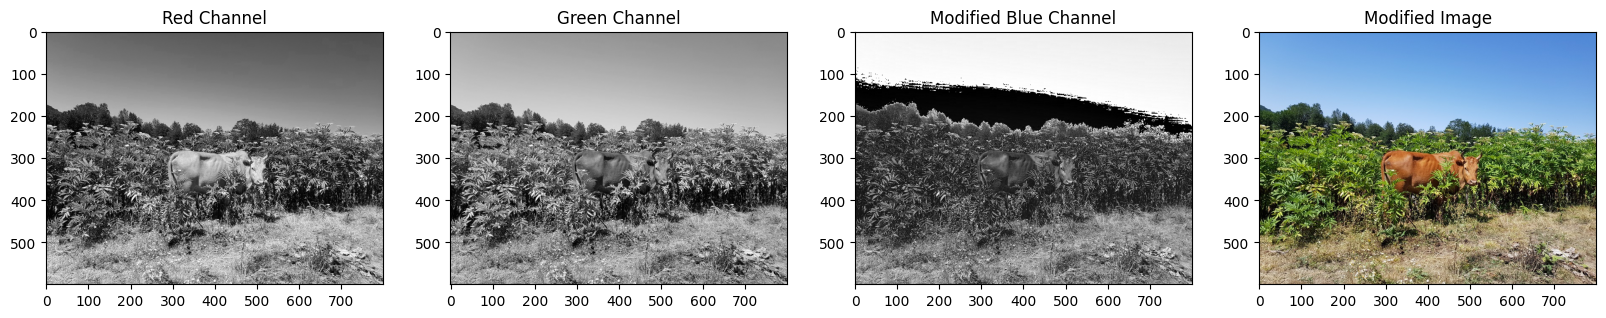

In [ ]:
img = cv2.imread(input_image_path)
b, g, r = cv2.split(img)

modified_b = b + 20
merged = cv2.merge([modified_b, g, r])

plt.figure(figsize=([20, 5]))
plt.subplot(141);plt.imshow(r, cmap='gray');plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap='gray');plt.title("Green Channel")
plt.subplot(143);plt.imshow(modified_b, cmap='gray');plt.title("Modified Blue Channel")

plt.subplot(144);plt.imshow(img[:, :, ::-1]);plt.title("Modified Image")

Text(0.5, 1.0, 'Modified Image')

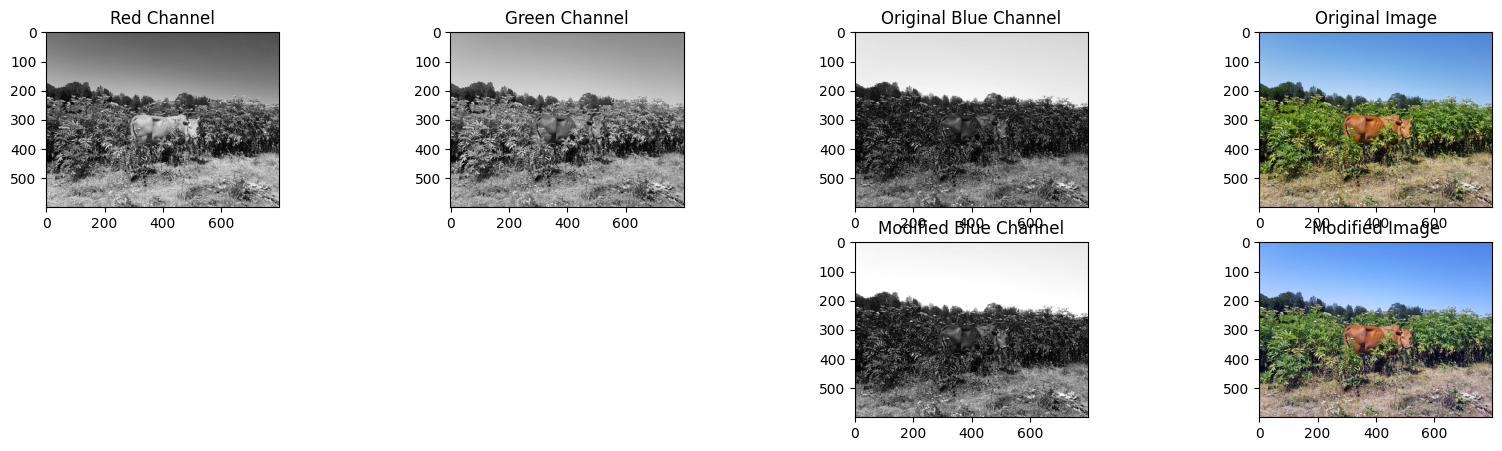

In [ ]:
modified_b = b.astype('int16') + 20
modified_b = np.minimum(modified_b, 255)
modified_b = modified_b.astype('uint8')

merged = cv2.merge([modified_b, g, r])
plt.figure(figsize=([20, 5]))
plt.subplot(241);plt.imshow(r, cmap='gray');plt.title("Red Channel")
plt.subplot(242);plt.imshow(g, cmap='gray');plt.title("Green Channel")
plt.subplot(243);plt.imshow(b, cmap='gray');plt.title("Original Blue Channel")
plt.subplot(244);plt.imshow(img[:, :, ::-1]);plt.title("Original Image")

plt.subplot(247);plt.imshow(modified_b, cmap='gray');plt.title("Modified Blue Channel")
plt.subplot(248);plt.imshow(merged[:, :, ::-1]);plt.title("Modified Image")

In [ ]:
assert np.all(modified_b == cv2.add(b, 20))

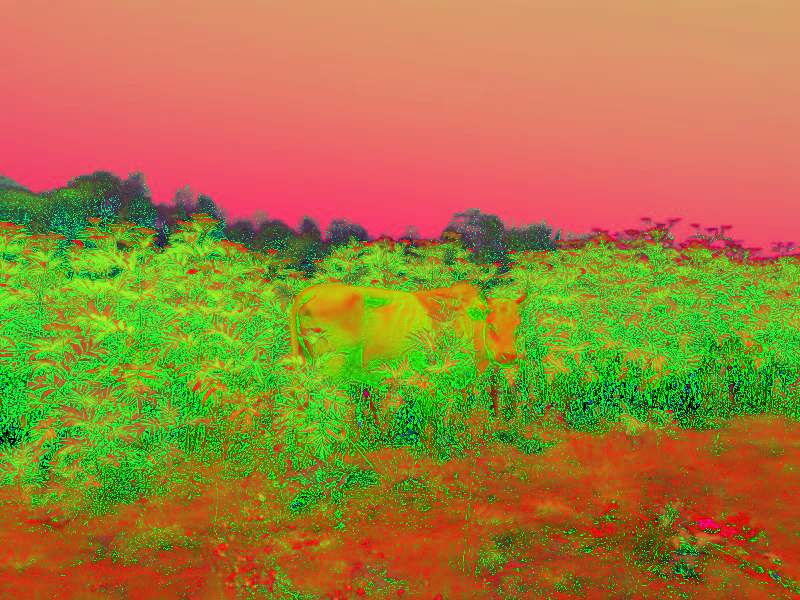

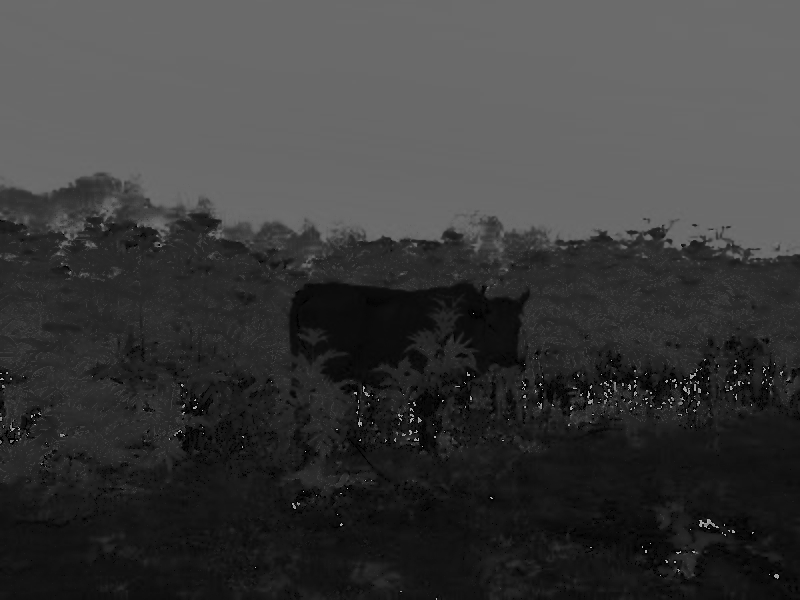

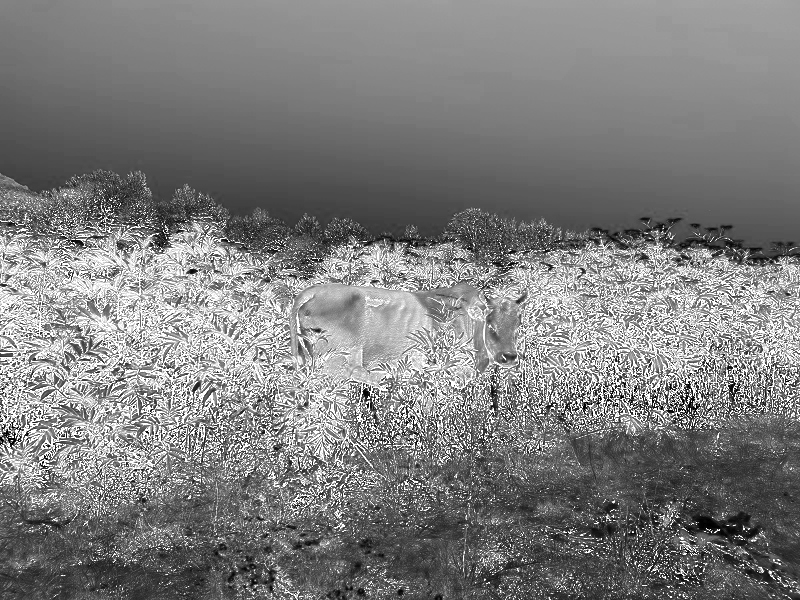

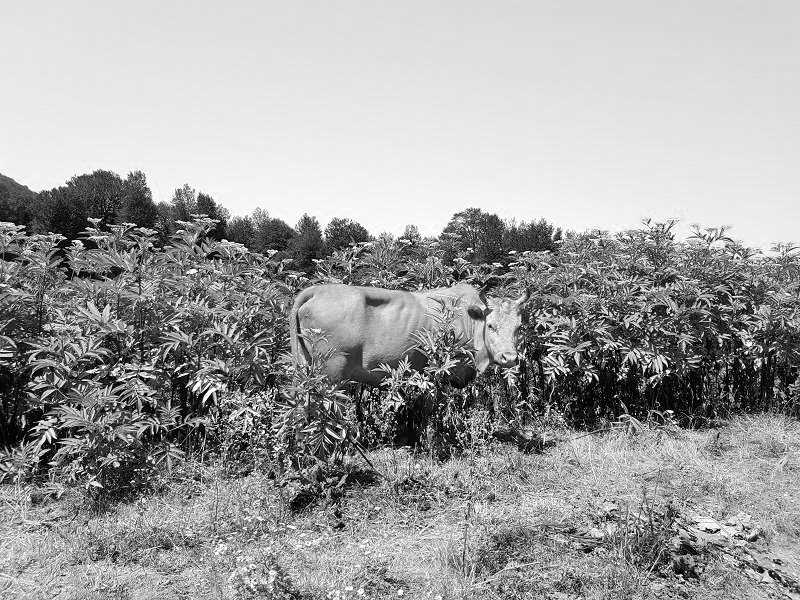

In [ ]:
img = cv2.imread(input_image_path)
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

cv2_imshow(hsv_image)
cv2_imshow(hsv_image[:, :, 0])
cv2_imshow(hsv_image[:, :, 1])
cv2_imshow(hsv_image[:, :, 2])

Text(0.5, 1.0, 'Value Channel')

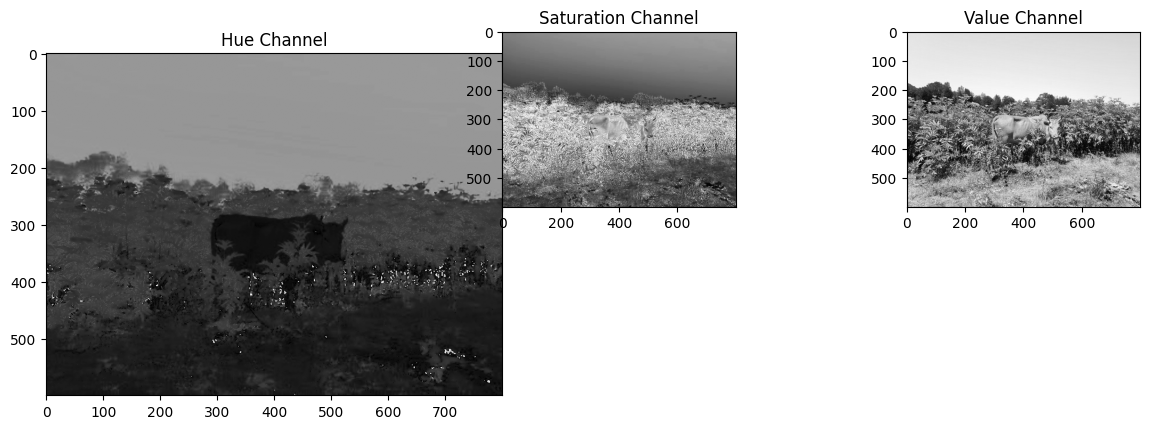

In [ ]:
plt.figure(figsize=([20, 5]))
plt.subplot(131);plt.imshow(hsv_image[:, :, 0], cmap='gray');plt.title("Hue Channel")
plt.subplot(242);plt.imshow(hsv_image[:, :, 1], cmap='gray');plt.title("Saturation Channel")
plt.subplot(243);plt.imshow(hsv_image[:, :, 2], cmap='gray');plt.title("Value Channel")

Text(0.5, 1.0, 'Original Image')

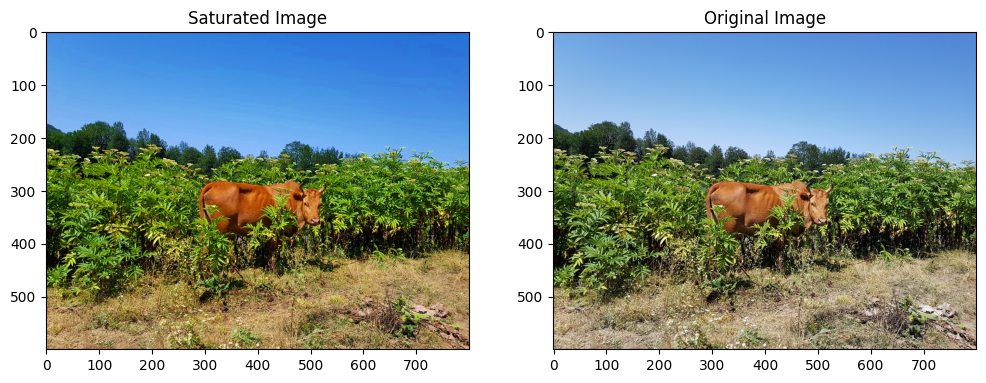

In [ ]:
saturated_image = cv2.merge([hsv_image[:, :, 0], cv2.add(hsv_image[:, :, 1], 50), hsv_image[:, :, 2]])
saturated_image = cv2.cvtColor(saturated_image, cv2.COLOR_HSV2BGR)

plt.figure(figsize=[12, 5])
plt.subplot(121)
plt.imshow(saturated_image[..., ::-1])
plt.title('Saturated Image')

plt.subplot(122)
plt.imshow(img[..., ::-1])
plt.title('Original Image')

Text(0.5, 1.0, 'Original Image')

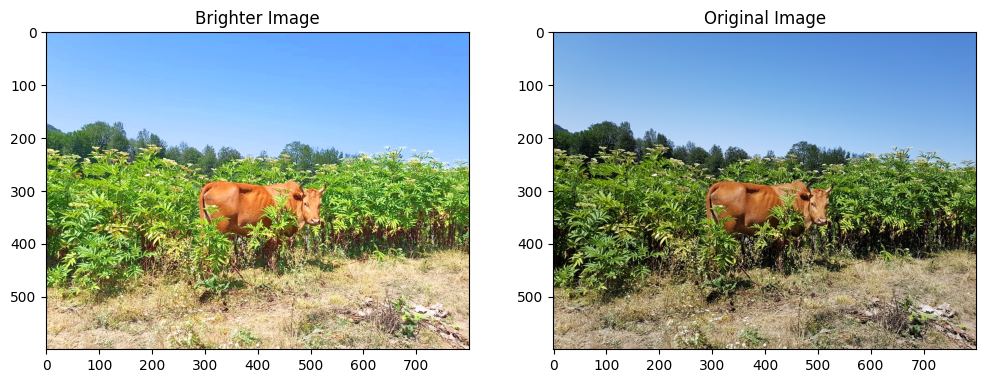

In [ ]:
brighter_image = cv2.merge([hsv_image[:, :, 0], hsv_image[:, :, 1], cv2.add(hsv_image[:, :, 2], 50)])
brighter_image = cv2.cvtColor(brighter_image, cv2.COLOR_HSV2BGR)

plt.figure(figsize=[12, 5])
plt.subplot(121)
plt.imshow(brighter_image[..., ::-1])
plt.title('Brighter Image')

plt.subplot(122)
plt.imshow(img[..., ::-1])
plt.title('Original Image')